# Imports and Setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from ucimlrepo import fetch_ucirepo 

# Data Fetching & Preprocessing

In [12]:
print("Fetching dataset...")
metro_interstate_traffic_volume = fetch_ucirepo(id=492) 
X = metro_interstate_traffic_volume.data.features 
y = metro_interstate_traffic_volume.data.targets 

df = X.copy()
df['traffic_volume'] = y

print("Processing features...")
# Convert to datetime and extract useful time features
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
# 1 if weekend, 0 if weekday
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Select the final features for the model
features_to_use = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'is_weekend']
X_processed = df[features_to_use]
y_processed = df['traffic_volume']

print("Data processing complete!")

Fetching dataset...
Processing features...
Data processing complete!


# Model Training

In [13]:
print("Splitting data into Train (70%), Validate (15%), and Test (15%) sets...")

# First split: 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X_processed, y_processed, test_size=0.30, random_state=42)

# Second split: Cut the Temp set in half to get 15% Val and 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training rows: {len(X_train)} | Validation rows: {len(X_val)} | Testing rows: {len(X_test)}")

print("Scaling data and training Neural Network...")
# Neural networks need data scaled between 0 and 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train the Neural Network
nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32), 
    max_iter=2000,         # Give it up to 2000 steps to find the lowest error
    early_stopping=True,   # Stop early if the score stops improving
    random_state=42
)
nn_model.fit(X_train_scaled, y_train)

# Generate Predictions
val_predictions = nn_model.predict(X_val_scaled)
test_predictions = nn_model.predict(X_test_scaled)

Splitting data into Train (70%), Validate (15%), and Test (15%) sets...
Training rows: 33742 | Validation rows: 7231 | Testing rows: 7231
Scaling data and training Neural Network...


# Evaluation Metrics

In [14]:
def print_metrics(dataset_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n--- {dataset_name} Results ---")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f} cars")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} cars")

print_metrics("Validation Set", y_val, val_predictions)
print_metrics("Test Set", y_test, test_predictions)


--- Validation Set Results ---
R-squared (R²): 0.9332
Mean Absolute Error (MAE): 306.63 cars
Root Mean Squared Error (RMSE): 515.27 cars

--- Test Set Results ---
R-squared (R²): 0.9385
Mean Absolute Error (MAE): 302.32 cars
Root Mean Squared Error (RMSE): 494.64 cars


# Generating the Plots

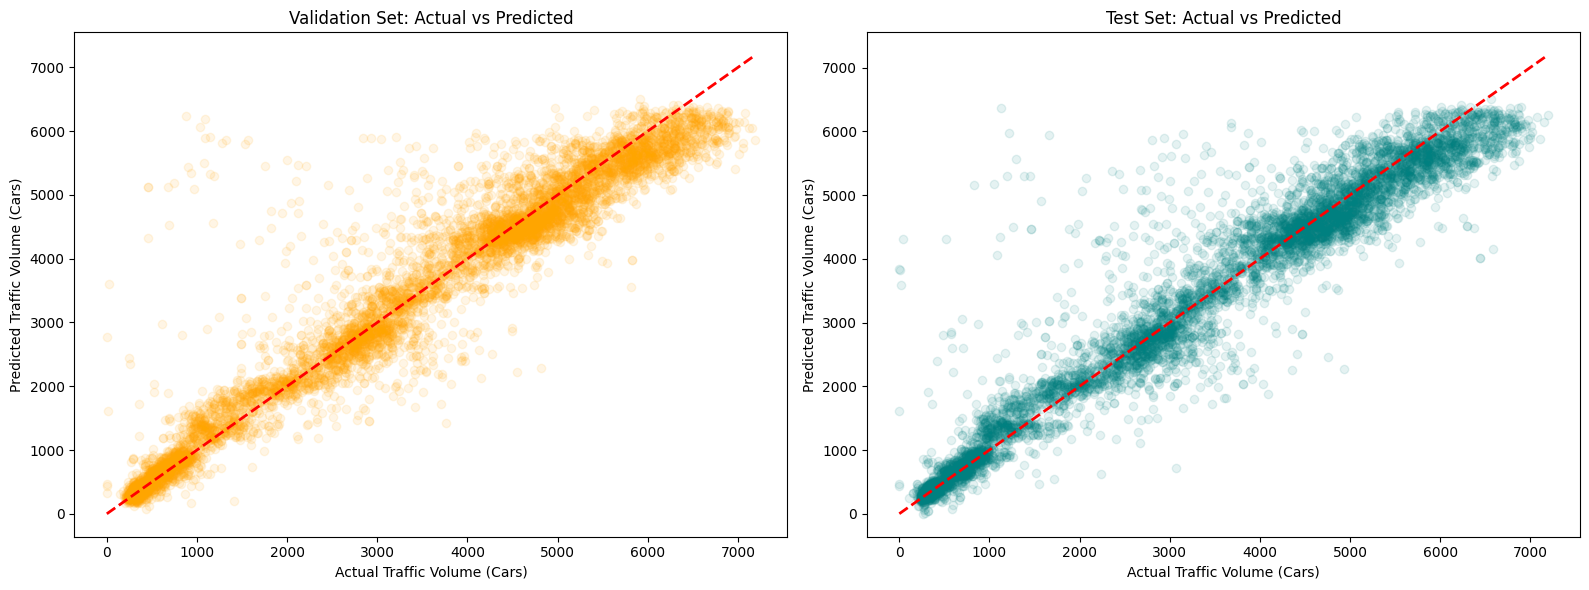

AttributeError: 'MLPRegressor' object has no attribute 'feature_importances_'

In [ ]:
# 1. Validation and Test Scatter Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(y_val, val_predictions, alpha=0.1, color='orange')
ax1.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Traffic Volume (Cars)')
ax1.set_ylabel('Predicted Traffic Volume (Cars)')
ax1.set_title('Validation Set: Actual vs Predicted')

ax2.scatter(y_test, test_predictions, alpha=0.1, color='teal')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Traffic Volume (Cars)')
ax2.set_ylabel('Predicted Traffic Volume (Cars)')
ax2.set_title('Test Set: Actual vs Predicted')

plt.tight_layout()
plt.show()